In [9]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib notebook

In [4]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [30]:
seq_sums = []
seq_pars = []
seq_pos = []
for asset in assets:
    try:
        print(asset.session_id)
        derived_dir = asset.derived_dir / 'glutamate' /'glutamate_analysis'
        seq_sum = pd.read_csv(os.path.join(derived_dir, 'sequence_summary_table.csv'))
        seq_sum['dmd1_depth'] = [asset.metadata['dmd1_depth']]*len(seq_sum)
        seq_sum['dmd2_depth'] = [asset.metadata['dmd2_depth']]*len(seq_sum)
        seq_par = pd.read_parquet(derived_dir / 'sequence_per_image_table.parquet')
        seq_pos_ = pd.read_parquet(derived_dir / 'sequence_position_table.parquet')
        seq_sums.append(seq_sum)

        seq_pars.append(seq_par)
        seq_pos.append(seq_pos_)
    except:
        pass

seq_summary = pd.concat(seq_sums)
seq_per_image = pd.concat(seq_pars)
seq_position = pd.concat(seq_pos)

803496_2025-07-25_13-02-10
803496_2025-07-28_08-04-39
803496_2025-07-29_13-34-35
803496_2025-07-30_10-05-23
803496_2025-07-31_09-43-28
803496_2025-08-01_13-22-49
804730_2025-07-25_14-08-35
804730_2025-07-28_13-57-34
804730_2025-07-29_14-55-04
804730_2025-07-30_11-11-11
804730_2025-07-31_11-45-27
804730_2025-08-01_14-22-38
804733_2025-07-25_15-17-00
804733_2025-07-28_19-00-06
804733_2025-07-29_16-02-24
804733_2025-07-30_12-59-44
804733_2025-07-31_13-29-01
804733_2025-08-01_15-20-32
810196_2025-07-25_16-24-20
810196_2025-07-28_19-59-05
810196_2025-07-29_17-02-41
810196_2025-07-31_08-28-08
810196_2025-07-31_14-19-46
810196_2025-08-01_16-37-27
809047_2025-10-29_10-16-32
809047_2025-10-30_10-06-43
809047_2025-10-31_12-00-50
809047_2025-11-01_17-51-59
809047_2025-11-05_10-13-00
809047_2025-11-06_11-05-31
803121_2025-10-29_11-19-29
803121_2025-10-30_11-13-32
803121_2025-10-31_13-05-26
803121_2025-11-01_19-00-21
803121_2025-11-05_11-16-57
803121_2025-11-06_12-12-23
826033_2026-02-21_09-23-34
8

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_30880\3161649996.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  seq_summary = pd.concat(seq_sums)


In [31]:
seq_summary['sequence_class'].unique()

array(['stable', 'late_facilitating'], dtype=object)

In [25]:
r25 = [normalize([s['median_r0'],s['median_rlast'],s['median_rterminal']]) for idx,s in seq_summary.iterrows() if abs(s['median_adaptation_index'])<=0.5 and s['dmd']=='DMD1' and s['dmd1_depth']==25.0 or abs(s['median_adaptation_index'])<=0.5 and s['dmd']=='DMD2' and s['dmd2_depth']==25.0]
r100 = [normalize([s['median_r0'],s['median_rlast'],s['median_rterminal']]) for idx,s in seq_summary.iterrows() if abs(s['median_adaptation_index'])<=0.5 and s['dmd']=='DMD2' and s['dmd2_depth']==100.0]
r200 = [normalize([s['median_r0'],s['median_rlast'],s['median_rterminal']]) for idx,s in seq_summary.iterrows() if  abs(s['median_adaptation_index'])<=0.5 and s['dmd']=='DMD2' and s['dmd2_depth']==200.0 or abs(s['median_adaptation_index'])<=0.5 and s['dmd']=='DMD1' and s['dmd1_depth']==200.0]
r250 = [normalize([s['median_r0'],s['median_rlast'],s['median_rterminal']]) for idx,s in seq_summary.iterrows() if abs(s['median_adaptation_index'])<=0.5 and s['dmd2_depth']==250.0]

<IPython.core.display.Javascript object>


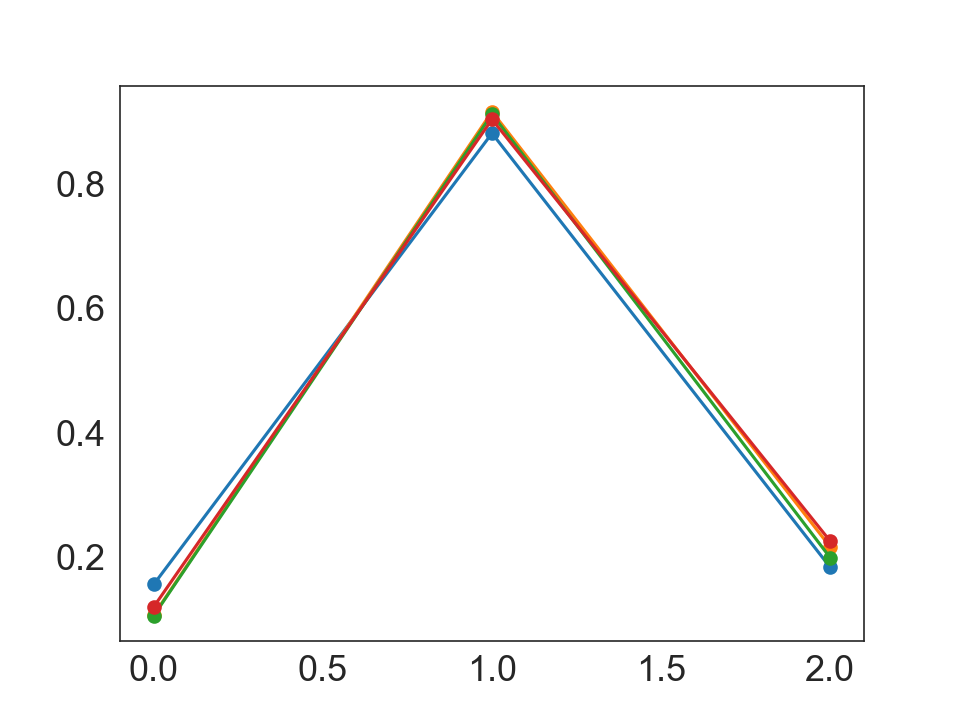

In [26]:
# Response amplitude x response position

fig,ax=plt.subplots()

for response in [r25,r100,r200,r250]:
    mean = np.mean(response,axis=0)
    ax.plot(mean,marker='o')

In [29]:
seq_per_image

,session_id,subject_id,dmd,synapse_id,stimulus_name,stimulus_label,n_positions,n_sequences,r0,rlast,...,overall_slope,overall_slope_norm,early_slope,late_slope,sequence_label,image_selectivity_score,ranking_score,image_rank_within_synapse,rank_basis,is_preferred_ranked_image
0,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk01378.tiff,imk01378,21,40,4.135909,-3.317766,...,0.176119,0.042583,-0.015838,0.653529,stable,-34.922383,45.880193,5,response_amplitude,False
1,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk01220.tiff,imk01220,17,40,4.002009,3.400045,...,0.314888,0.078682,0.139810,1.405141,stable,64.178829,130.824089,2,response_amplitude,False
2,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk00459.tiff,imk00459,16,40,2.642996,11.732948,...,0.526522,0.199214,0.181800,1.475654,stable,-14.799073,63.128745,4,response_amplitude,False
3,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk01643.tiff,imk01643,13,39,3.792312,5.586604,...,0.053110,0.014005,0.095214,-0.118465,stable,156.407801,209.877494,1,response_amplitude,True
4,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk00942.tiff,imk00942,14,39,9.852383,9.400597,...,-0.567097,-0.057559,-0.757631,0.229945,stable,-96.587349,-6.975492,7,response_amplitude,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\69022.tiff,69022,14,41,4.139674,2.922333,...,-0.229843,-0.055522,-0.097099,-0.697211,stable,9.523214,40.676187,3,response_amplitude,False
3,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\McGill_stairs.tiff,McGill_stairs,13,42,3.433658,5.620232,...,0.388975,0.113283,0.261582,0.773428,stable,-23.648170,12.243572,6,response_amplitude,False
4,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\216066.tiff,216066,15,42,1.891201,-0.229533,...,0.089876,0.047523,-0.035940,0.485189,stable,-36.478776,1.245909,7,response_amplitude,False
5,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\41006.tiff,41006,17,41,5.208662,27.667132,...,0.153581,0.029486,-0.248456,1.619099,stable,-9.750158,24.156154,5,response_amplitude,False


In [39]:
dft = seq_per_image[seq_per_image['sequence_label']!='stable']
dft

,session_id,subject_id,dmd,synapse_id,stimulus_name,stimulus_label,n_positions,n_sequences,r0,rlast,...,overall_slope,overall_slope_norm,early_slope,late_slope,sequence_label,image_selectivity_score,ranking_score,image_rank_within_synapse,rank_basis,is_preferred_ranked_image
262,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0071,stimuli\images_A\imk01643.tiff,imk01643,13,39,11.377763,-0.740013,...,0.978843,0.086031,-0.044852,5.150468,late_facilitating,200.629375,200.629375,3,selectivity_score,False
349,803496_2025-07-25_13-02-10,803496,DMD2,DMD2_syn0005,stimuli\images_A\imk01057.tiff,imk01057,18,38,3.704185,36.482160,...,1.126721,0.304175,-0.267134,5.418121,late_facilitating,-12.426678,11.630860,4,response_amplitude,False
932,803496_2025-07-30_10-05-23,803496,DMD2,DMD2_syn0066,stimuli\images_B\imk01306.tiff,imk01306,13,40,0.746746,4.944687,...,2.298172,3.077582,5.767041,-5.946903,biphasic_adapting,114.001125,151.770112,1,response_amplitude,True
172,803496_2025-07-31_09-43-28,803496,DMD1,DMD1_syn0029,stimuli\images_B\216066.tiff,216066,22,39,23.554204,78.417230,...,1.986428,0.084334,0.781802,5.588955,late_facilitating,319.569381,319.569381,2,selectivity_score,False
26,803496_2025-08-01_13-22-49,803496,DMD1,DMD1_syn0007,stimuli\images_B\100075.tiff,100075,19,38,52.561900,102.035917,...,0.806718,0.015348,-1.486183,7.934993,late_facilitating,859.535753,859.535753,1,selectivity_score,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0096,stimuli\images_B\69022.tiff,69022,15,32,210.354124,152.573714,...,30.845289,0.146635,6.098746,108.929130,late_facilitating,5249.911960,5249.911960,1,selectivity_score,True
720,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0098,stimuli\images_B\69022.tiff,69022,15,32,403.026816,735.946666,...,7.343220,0.018220,-3.869270,42.722477,late_facilitating,4441.269621,4441.269621,2,selectivity_score,False
727,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0099,stimuli\images_B\69022.tiff,69022,15,32,123.297617,730.538136,...,7.347312,0.059590,-1.523911,35.339067,late_facilitating,-315.281153,-315.281153,3,selectivity_score,False
728,803121_2025-11-01_19-00-21,803121,DMD2,DMD2_syn0100,stimuli\images_B\McGill_stairs.tiff,McGill_stairs,19,33,168.641678,367.862904,...,11.503398,0.068212,6.076900,26.374122,late_facilitating,-297.141843,-297.141843,4,selectivity_score,False


<IPython.core.display.Javascript object>


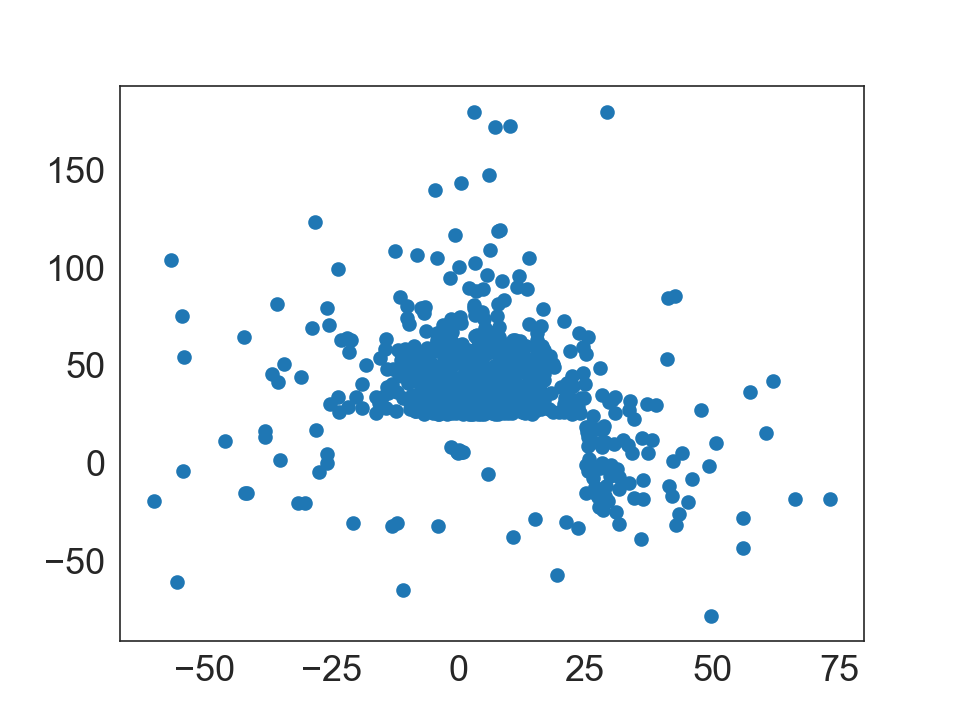

In [40]:
fig,ax=plt.subplots()

ax.scatter(dft['early_slope'],dft['late_slope'])

NameError: name 'np' is not defined